In [4]:
import pandas as pd
import numpy as  np
# Load file
file_path =r"C:\Users\DEEPI\Documents\PROJECT\DS Project 2\ICRISAT-District Level Data.xlsx"
df = pd.read_excel(file_path)
df

,Dist Code,Year,State Code,State Name,Dist Name,RICE AREA (1000 ha),RICE PRODUCTION (1000 tons),RICE YIELD (Kg per ha),WHEAT AREA (1000 ha),WHEAT PRODUCTION (1000 tons),...,SUGARCANE YIELD (Kg per ha),COTTON AREA (1000 ha),COTTON PRODUCTION (1000 tons),COTTON YIELD (Kg per ha),FRUITS AREA (1000 ha),VEGETABLES AREA (1000 ha),FRUITS AND VEGETABLES AREA (1000 ha),POTATOES AREA (1000 ha),ONION AREA (1000 ha),FODDER AREA (1000 ha)
0,1,1966,14,Chhattisgarh,Durg,548.00,185.00,337.59,44.00,20.00,...,1777.78,0.0,0.0,0.0,5.95,6.64,12.59,0.01,0.60,0.47
1,1,1967,14,Chhattisgarh,Durg,547.00,409.00,747.71,50.00,26.00,...,1500.00,0.0,0.0,0.0,5.77,7.24,13.02,0.01,0.56,1.23
2,1,1968,14,Chhattisgarh,Durg,556.30,468.00,841.27,53.70,30.00,...,1000.00,0.0,0.0,0.0,5.41,7.40,12.81,0.10,0.58,1.02
3,1,1969,14,Chhattisgarh,Durg,563.40,400.80,711.40,49.40,26.50,...,1900.00,0.0,0.0,0.0,5.52,7.16,12.69,0.01,0.56,0.84
4,1,1970,14,Chhattisgarh,Durg,571.60,473.60,828.55,44.20,29.00,...,2000.00,0.0,0.0,0.0,5.45,7.19,12.64,0.02,0.52,0.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16141,917,2013,15,Jharkhand,Singhbhum,267.06,579.70,2170.67,1.53,1.85,...,0.00,0.0,0.0,0.0,0.00,9.02,9.03,0.48,0.08,0.00
16142,917,2014,15,Jharkhand,Singhbhum,256.33,586.63,2288.57,5.36,6.65,...,0.00,0.0,0.0,0.0,0.00,8.63,8.64,0.46,0.04,0.00
16143,917,2015,15,Jharkhand,Singhbhum,263.21,264.71,1005.70,1.99,1.82,...,0.00,0.0,0.0,0.0,0.00,6.84,6.85,0.42,0.01,0.00
16144,917,2016,15,Jharkhand,Singhbhum,224.05,319.01,1423.84,0.38,0.83,...,0.00,0.0,0.0,0.0,0.03,6.40,6.43,0.03,0.01,0.00


In [5]:
# Shape of dataset
print("Shape:", df.shape)

# Structure check
df.head()

Shape: (16146, 80)


,Dist Code,Year,State Code,State Name,Dist Name,RICE AREA (1000 ha),RICE PRODUCTION (1000 tons),RICE YIELD (Kg per ha),WHEAT AREA (1000 ha),WHEAT PRODUCTION (1000 tons),...,SUGARCANE YIELD (Kg per ha),COTTON AREA (1000 ha),COTTON PRODUCTION (1000 tons),COTTON YIELD (Kg per ha),FRUITS AREA (1000 ha),VEGETABLES AREA (1000 ha),FRUITS AND VEGETABLES AREA (1000 ha),POTATOES AREA (1000 ha),ONION AREA (1000 ha),FODDER AREA (1000 ha)
0,1,1966,14,Chhattisgarh,Durg,548.0,185.0,337.59,44.0,20.0,...,1777.78,0.0,0.0,0.0,5.95,6.64,12.59,0.01,0.60,0.47
1,1,1967,14,Chhattisgarh,Durg,547.0,409.0,747.71,50.0,26.0,...,1500.00,0.0,0.0,0.0,5.77,7.24,13.02,0.01,0.56,1.23
2,1,1968,14,Chhattisgarh,Durg,556.3,468.0,841.27,53.7,30.0,...,1000.00,0.0,0.0,0.0,5.41,7.40,12.81,0.10,0.58,1.02
3,1,1969,14,Chhattisgarh,Durg,563.4,400.8,711.40,49.4,26.5,...,1900.00,0.0,0.0,0.0,5.52,7.16,12.69,0.01,0.56,0.84
4,1,1970,14,Chhattisgarh,Durg,571.6,473.6,828.55,44.2,29.0,...,2000.00,0.0,0.0,0.0,5.45,7.19,12.64,0.02,0.52,0.42


In [6]:
# Standardize Column Names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "")
    .str.replace(")", "")
)
# Prevents syntax errors
# Makes column handling easy

In [7]:
# Check Missing Values
df.isnull().sum().sort_values(ascending=False)

dist_code                             0
year                                  0
state_code                            0
state_name                            0
dist_name                             0
                                     ..
vegetables_area_1000_ha               0
fruits_and_vegetables_area_1000_ha    0
potatoes_area_1000_ha                 0
onion_area_1000_ha                    0
fodder_area_1000_ha                   0
Length: 80, dtype: int64

In [8]:
# Numeric Column filled with 0
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(0)
# Categorical Column filled with "Unknown"
cat_cols = df.select_dtypes(include="object").columns
df[cat_cols] = df[cat_cols].fillna("Unknown")

In [9]:
# Fix Data Types
df["year"] = df["year"].astype(int)
df["state_name"] = df["state_name"].astype(str)
df["dist_name"] = df["dist_name"].astype(str)

In [10]:
# Remove duplicate records
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicates: 0


In [11]:
# Remove invalid values
df[num_cols] = df[num_cols].clip(lower=0)

In [12]:
# Unit Conversion
if "rice_area_1000_ha" in df.columns:
    df["rice_area_ha"] = df["rice_area_1000_ha"] * 1000

In [13]:
# Save Cleaned Data
df.to_csv("cleaned_agriculture_data.csv", index=False)

In [14]:
# Start EDA
df.head()
df.shape
df.columns

# Load cleaned data
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("cleaned_agriculture_data.csv")

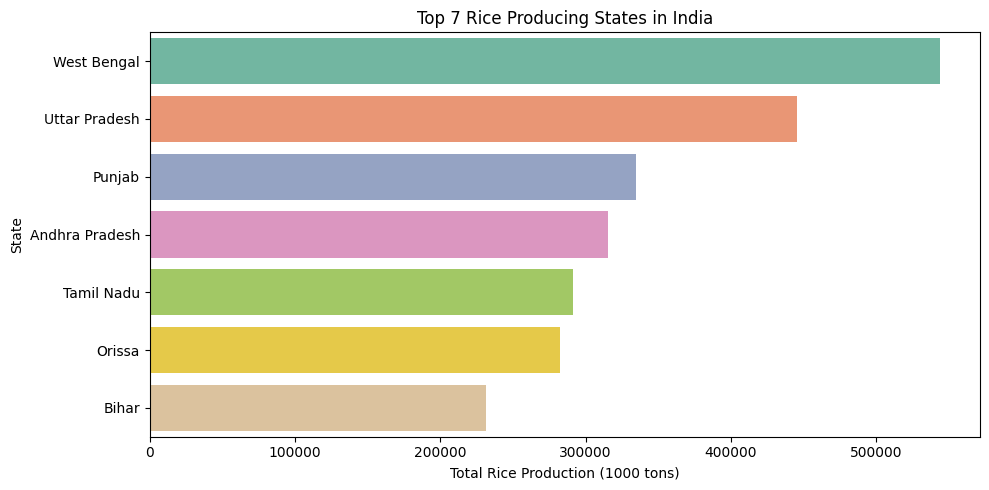

In [15]:
# 1) Top 7 RICE PRODUCTION State Data (Bar_plot)
# Aggregate rice production by state
top_7_rice_states = (
    df.groupby("state_name")["rice_production_1000_tons"]
    .sum()
    .sort_values(ascending=False)
    .head(7)
    .reset_index()
)
# Set color palette with 7 different color
palette = sns.color_palette("Set2", n_colors=7)

# Plot
plt.figure(figsize=(10,5))
sns.barplot(
    data=top_7_rice_states,
    x="rice_production_1000_tons",
    y="state_name",
    hue="state_name",
    palette="Set2",
    legend=False
)

plt.title("Top 7 Rice Producing States in India")
plt.xlabel("Total Rice Production (1000 tons)")
plt.ylabel("State")
plt.tight_layout()
plt.show()  


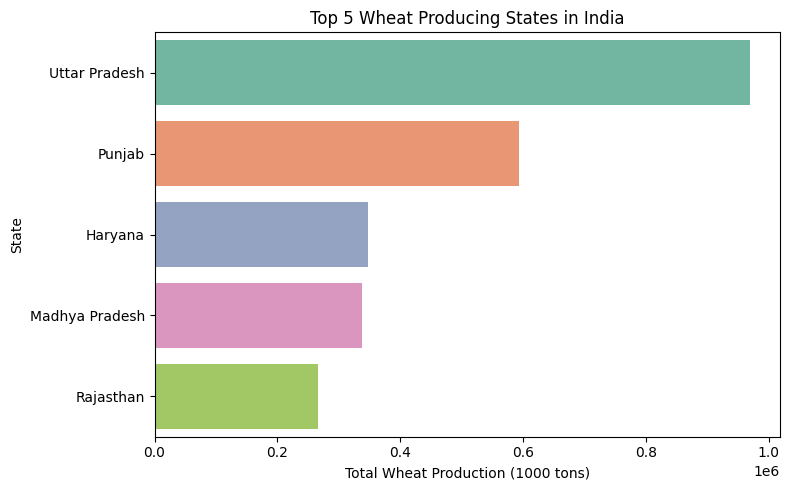

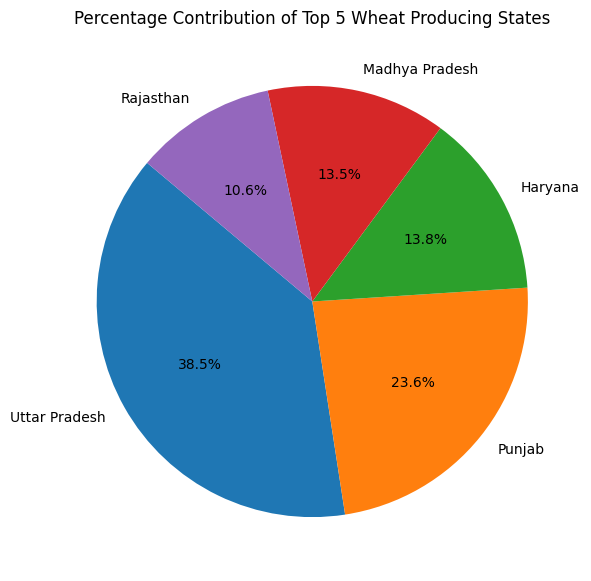

In [16]:
# 2) Top 5 Wheat Producing States Data(Bar_chart)and its percentage(%)(Pie_chart)
# Aggregate wheat production by state
top_5_wheat_states = (
    df.groupby("state_name")["wheat_production_1000_tons"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

# Calculate percentage contribution
top_5_wheat_states["percentage"] = (
    top_5_wheat_states["wheat_production_1000_tons"] /
    top_5_wheat_states["wheat_production_1000_tons"].sum()
) * 100

# Bar Chart
plt.figure(figsize=(8,5))

sns.barplot(
    data=top_5_wheat_states,
    x="wheat_production_1000_tons",
    y="state_name",
    hue="state_name",
    palette="Set2",
    legend=False
)

plt.title("Top 5 Wheat Producing States in India")
plt.xlabel("Total Wheat Production (1000 tons)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

# Pie Chart
plt.figure(figsize=(7,7))

plt.pie(
    top_5_wheat_states["percentage"],
    labels=top_5_wheat_states["state_name"],
    autopct="%1.1f%%",
    startangle=140
)

plt.title("Percentage Contribution of Top 5 Wheat Producing States")
plt.show()


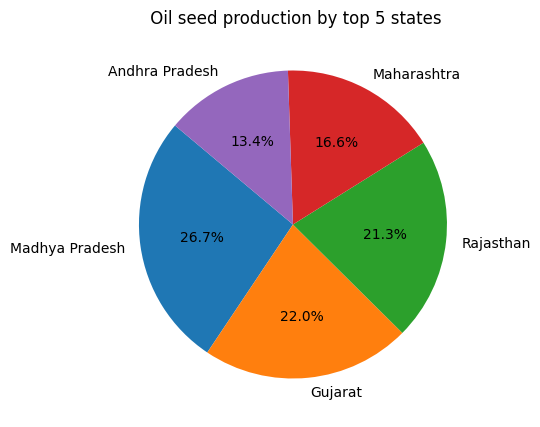

In [17]:
# 3) Oil seed production by top 5 states (Using Pie Chart by % myself to represent data)
top_5_oilseed_states = (
    df.groupby("state_name")["oilseeds_production_1000_tons"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

# Pie Chart
plt.figure(figsize=(5,5))

plt.pie(
    top_5_oilseed_states["oilseeds_production_1000_tons"],
    labels=top_5_oilseed_states["state_name"],
    autopct="%1.1f%%",
    startangle=140
)

plt.title(" Oil seed production by top 5 states")
plt.show()


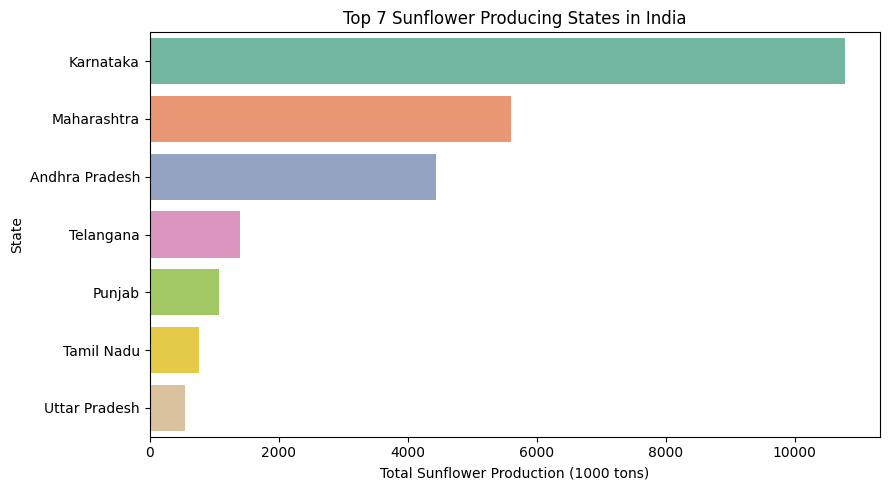

In [18]:
# 4) Top 7 SUNFLOWER PRODUCTION  State (Using Bar Chart myself to represent data)

top_7_sunflower_states = (
    df.groupby("state_name")["sunflower_production_1000_tons"]
    .sum()
    .sort_values(ascending=False)
    .head(7)
    .reset_index()
)

top_7_sunflower_states
# Bar Chart
plt.figure(figsize=(9,5))

sns.barplot(
    data=top_7_sunflower_states,
    x="sunflower_production_1000_tons",
    y="state_name",
    hue="state_name",
    palette="Set2",
    legend=False
)

plt.title("Top 7 Sunflower Producing States in India")
plt.xlabel("Total Sunflower Production (1000 tons)")
plt.ylabel("State")
plt.tight_layout()
plt.show()


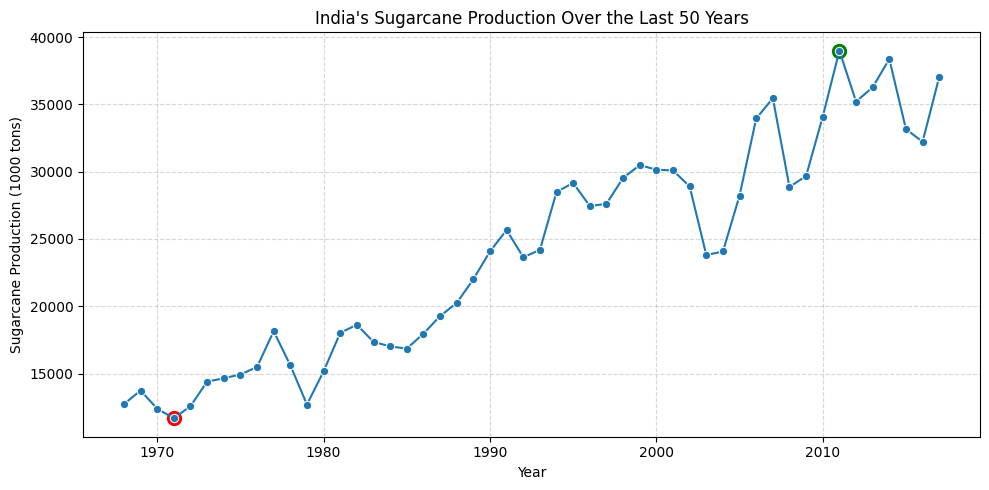

In [19]:
# 5) India's SUGARCANE PRODUCTION From Last 50 Years (Line_plot) 
sugarcane_yearly = (
    df.groupby("year")["sugarcane_production_1000_tons"]
    .sum()
    .reset_index()
    .sort_values("year")
)

# Filter last 50 years
last_50_years = sugarcane_yearly[
    sugarcane_yearly["year"] >= sugarcane_yearly["year"].max() - 49
]

# Identify High & Low Points
max_point = last_50_years.loc[
    last_50_years["sugarcane_production_1000_tons"].idxmax()
]

min_point = last_50_years.loc[
    last_50_years["sugarcane_production_1000_tons"].idxmin()
]

# Line Plot
plt.figure(figsize=(10,5))

sns.lineplot(
    data=last_50_years,
    x="year",
    y="sugarcane_production_1000_tons",
    marker="o"
)
# High point (GREEN)
plt.scatter(
    max_point["year"],
    max_point["sugarcane_production_1000_tons"],
    color="green",
    s=100,
    label="Highest Production"
)
# Low point (RED)
plt.scatter(
    min_point["year"],
    min_point["sugarcane_production_1000_tons"],
    color="red",
    s=100,
    label="Lowest Production"
)

plt.title("India's Sugarcane Production Over the Last 50 Years")
plt.xlabel("Year")
plt.ylabel("Sugarcane Production (1000 tons)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


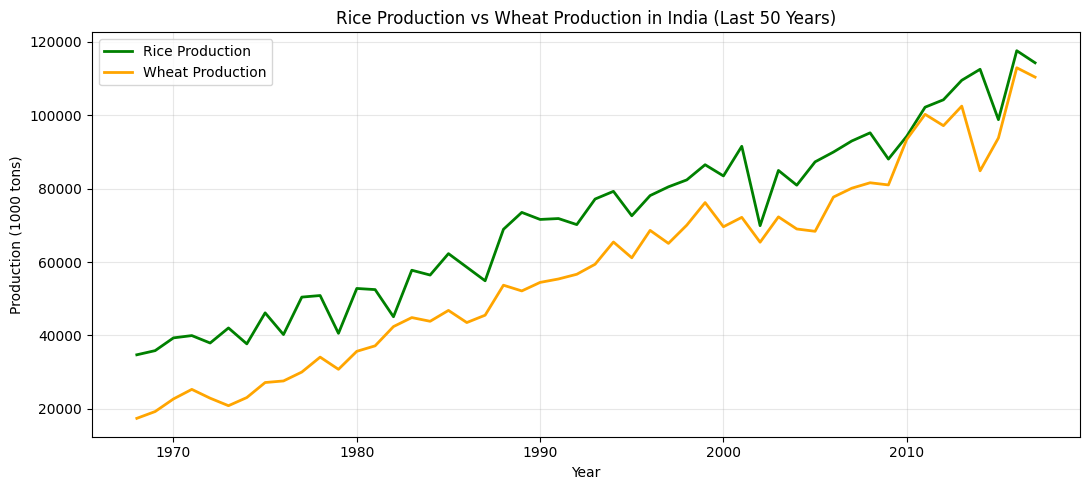

In [20]:
#  6) Rice Production Vs Wheat Production (Last 50y) 
yearly_prod = (
    df.groupby("year")[[
        "rice_production_1000_tons",
        "wheat_production_1000_tons"
    ]]
    .sum()
    .reset_index()
    .sort_values("year")
)
# Filter last 50 years
last_50_years = yearly_prod[
    yearly_prod["year"] >= yearly_prod["year"].max() - 49
]

# Line Plot
plt.figure(figsize=(11,5))

plt.plot(
    last_50_years["year"],
    last_50_years["rice_production_1000_tons"],
    color="green",
    linewidth=2,
    label="Rice Production"
)

plt.plot(
    last_50_years["year"],
    last_50_years["wheat_production_1000_tons"],
    color="orange",
    linewidth=2,
    label="Wheat Production"
)

plt.title("Rice Production vs Wheat Production in India (Last 50 Years)")
plt.xlabel("Year")
plt.ylabel("Production (1000 tons)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


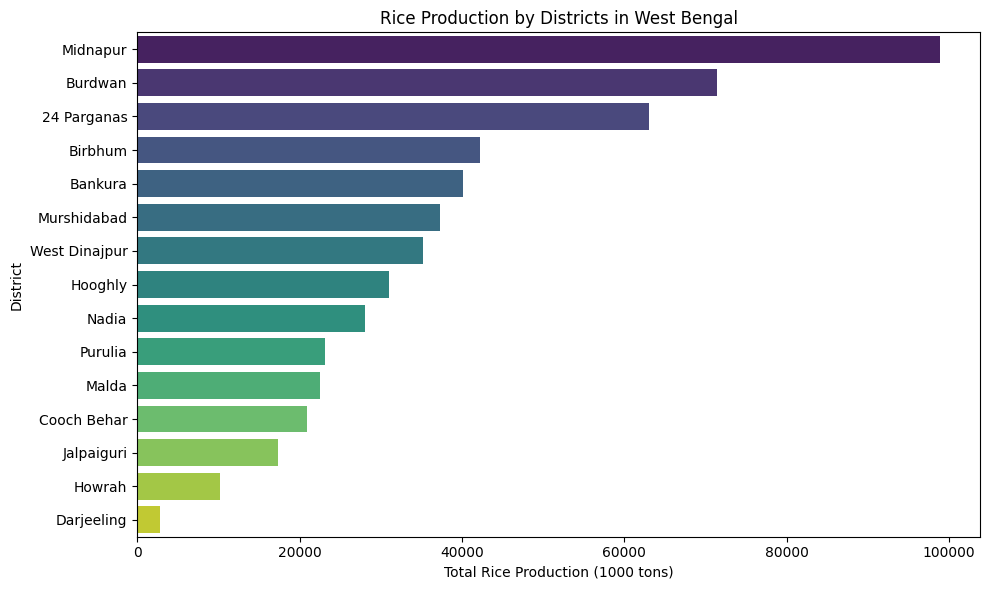

In [21]:
# 7) Rice Production By West Bengal Districts (Using Bar Chart myself to represent data)
# Filter West Bengal data
wb_rice = df[df["state_name"] == "West Bengal"]
# Aggregate Rice Production by District
wb_district_rice = (
    wb_rice.groupby("dist_name")["rice_production_1000_tons"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

wb_district_rice.head()

# Bar Chart
palette = sns.color_palette("viridis", n_colors=len(wb_district_rice))

plt.figure(figsize=(10,6))

sns.barplot(
    data=wb_district_rice,
    x="rice_production_1000_tons",
    y="dist_name",
    hue="dist_name",
    palette=palette
)

plt.title("Rice Production by Districts in West Bengal")
plt.xlabel("Total Rice Production (1000 tons)")
plt.ylabel("District")
plt.tight_layout()
plt.show()

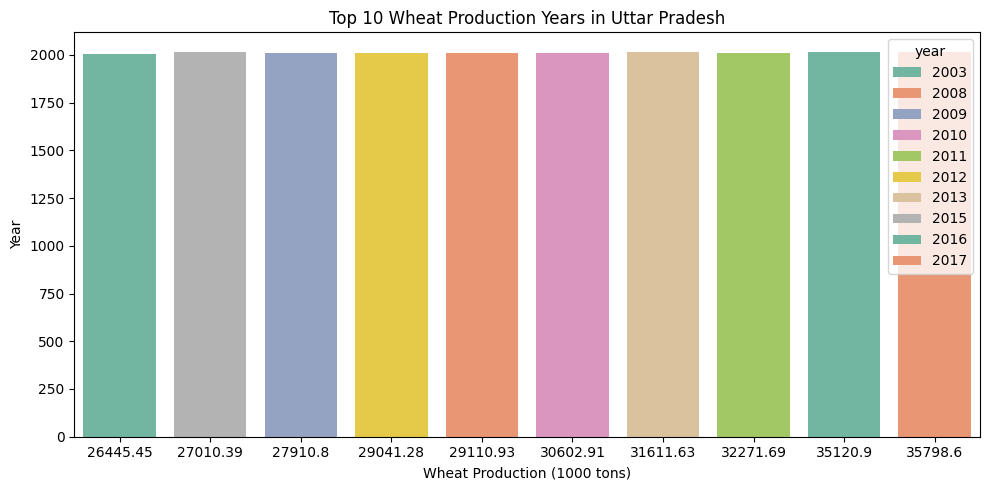

In [22]:
# 8) Top 10 Wheat Production Years From UP
# Filter Uttar Pradesh data
up_wheat = df[df["state_name"] == "Uttar Pradesh"]
# Aggregate Wheat Production by Year
up_wheat_yearly = (
    up_wheat.groupby("year")["wheat_production_1000_tons"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
up_wheat_yearly

# Bar Chart
plt.figure(figsize=(10,5))
sns.barplot(
    data=up_wheat_yearly,
    x="wheat_production_1000_tons",
    y="year",
    hue="year",
    palette="Set2"
)

plt.title("Top 10 Wheat Production Years in Uttar Pradesh")
plt.xlabel("Wheat Production (1000 tons)")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

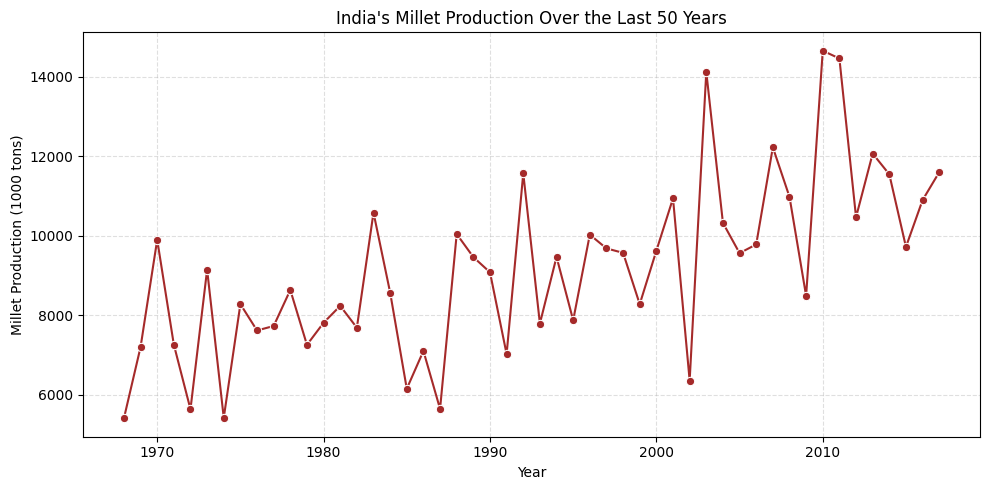

In [23]:
# 9) Millet Production (Last 50y) (Using Line Plot to represent data)
millet_yearly = (
    df.groupby("year")[[
        "pearl_millet_production_1000_tons",
        "finger_millet_production_1000_tons"
    ]]
    .sum()
    .sum(axis=1)           # sum across crops
    .reset_index(name="millet_production_1000_tons")
    .sort_values("year")
)
# Filter last 50 Years
last_50_years = millet_yearly[
    millet_yearly["year"] >= millet_yearly["year"].max() - 49
]
# Line Plot
plt.figure(figsize=(10,5))

sns.lineplot(
    data=last_50_years,
    x="year",
    y="millet_production_1000_tons",
    marker="o",
    color="brown"
)

plt.title("India's Millet Production Over the Last 50 Years")
plt.xlabel("Year")
plt.ylabel("Millet Production (1000 tons)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

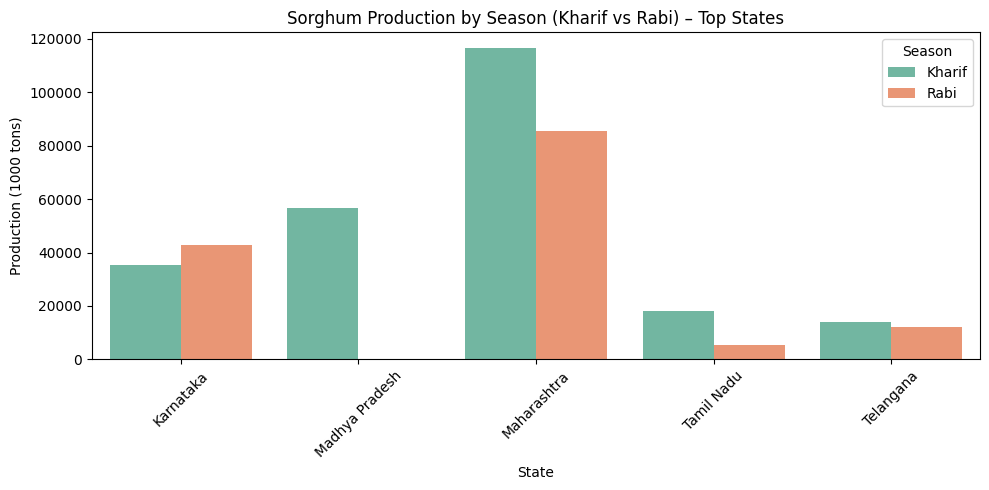

In [24]:
# 10) Sorghum Production (Kharif and Rabi) by Region (Using Bar Chart to represent data)
# Aggregate Sorghum Production by State & Season
sorghum_state = (
    df.groupby("state_name")[[
        "kharif_sorghum_production_1000_tons",
        "rabi_sorghum_production_1000_tons"
    ]]
    .sum()
    .reset_index()
)
# Reshape Data for Visualization
sorghum_melted = sorghum_state.melt(
    id_vars="state_name",
    value_vars=[
        "kharif_sorghum_production_1000_tons",
        "rabi_sorghum_production_1000_tons"
    ],
    var_name="Season",
    value_name="Production_1000_tons"
)
# Clean season names
sorghum_melted["Season"] = sorghum_melted["Season"].str.replace(
    "_sorghum_production_1000_tons", ""
).str.capitalize()
# Focus on Major Sorghum- Production States
top_states = (
    sorghum_state.assign(
        total=sorghum_state[
            "kharif_sorghum_production_1000_tons"
        ] + sorghum_state[
            "rabi_sorghum_production_1000_tons"
        ]
    )
    .sort_values("total", ascending=False)
    .head()["state_name"]
)
sorghum_top = sorghum_melted[
    sorghum_melted["state_name"].isin(top_states)
]
# Bar Chart - Kharif vs Rabi Sorghum
plt.figure(figsize=(10,5))
sns.barplot(
    data=sorghum_top,
    x="state_name",
    y="Production_1000_tons",
    hue="Season",
    palette="Set2"
)

plt.title("Sorghum Production by Season (Kharif vs Rabi) – Top States")
plt.xlabel("State")
plt.ylabel("Production (1000 tons)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


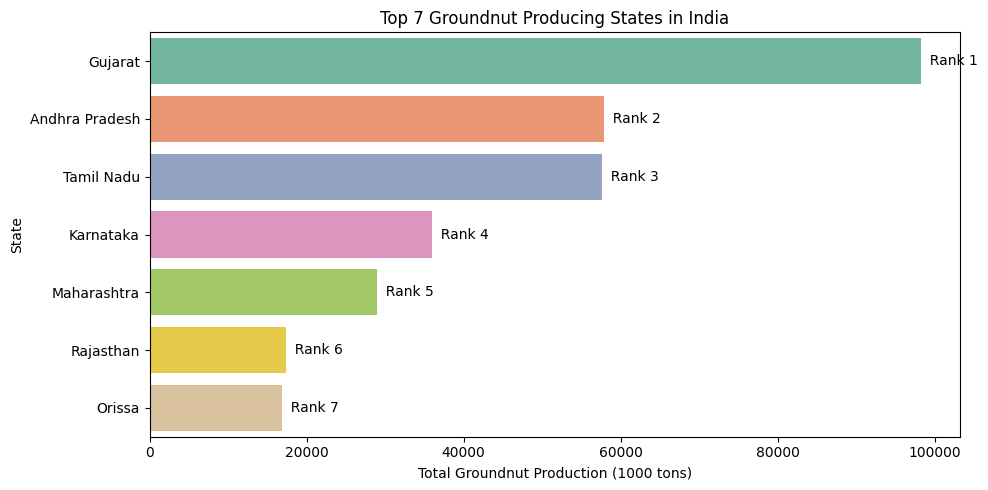

In [25]:
# 11) Top 7 States for Groundnut Production (Using Bar Chart to represent data)
# Aggregate Groundnut Production by State
top_7_groundnut_states = (
    df.groupby("state_name")["groundnut_production_1000_tons"]
    .sum()
    .sort_values(ascending=False)
    .head(7)
    .reset_index()
)

top_7_groundnut_states

# Bar Chart 
plt.figure(figsize=(10,5))
ax = sns.barplot(
    data=top_7_groundnut_states,
    x="groundnut_production_1000_tons",
    y="state_name",
    hue="state_name",
    palette="Set2"
)
# Add rank labels
for i, val in enumerate(top_7_groundnut_states["groundnut_production_1000_tons"]):
    ax.text(val, i, f"  Rank {i+1}", va="center")

plt.title("Top 7 Groundnut Producing States in India")
plt.xlabel("Total Groundnut Production (1000 tons)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

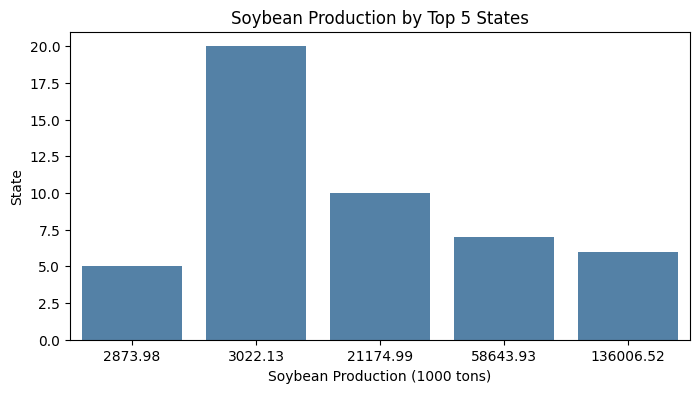

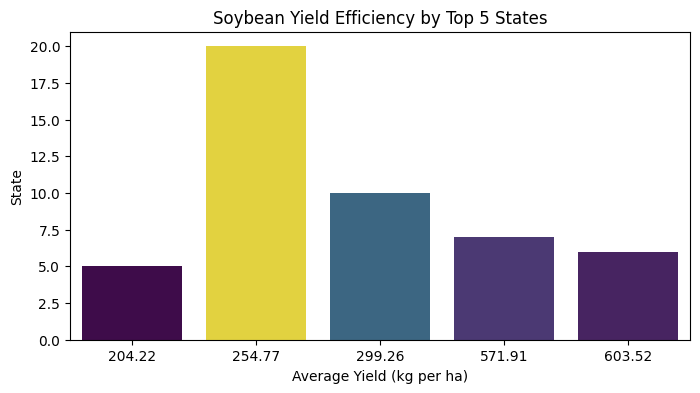

In [26]:
# 12) Soybean Production by Top 5 States and Yield Efficiency
# Identify Required Columns Automatically
state_col = [c for c in df.columns if "state" in c.lower()][0]
soy_prod_col = [c for c in df.columns if "soyabean" in c.lower() and "production" in c.lower()][0]
soy_yield_col = [c for c in df.columns if "soyabean" in c.lower() and "yield" in c.lower()][0]

state_col, soy_prod_col, soy_yield_col
# Top 5 Soybean State Data
top_5_soy_states = (
    df.groupby(state_col)
      .agg(
          soybean_production_1000_tons=(soy_prod_col, "sum"),
          soybean_yield_kg_per_ha=(soy_yield_col, "mean")
      )
      .sort_values("soybean_production_1000_tons", ascending=False)
      .head(5)
      .reset_index()
)

# Round yield to 2 decimals
top_5_soy_states["soybean_yield_kg_per_ha"] = (
    top_5_soy_states["soybean_yield_kg_per_ha"].round(2)
)

top_5_soy_states
# Bar Chart - Soybean Production
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))

sns.barplot(
    data=top_5_soy_states,
    x="soybean_production_1000_tons",
    y=state_col,
    color="steelblue"
)

plt.title("Soybean Production by Top 5 States")
plt.xlabel("Soybean Production (1000 tons)")
plt.ylabel("State")

plt.show()
plt.close()
# Bar Chart - Soybean Yield Efficiency
plt.figure(figsize=(8,4))

sns.barplot(
    data=top_5_soy_states,
    x="soybean_yield_kg_per_ha",
    y=state_col,
    hue=state_col,        
    palette="viridis",
    legend=False
)

plt.title("Soybean Yield Efficiency by Top 5 States")
plt.xlabel("Average Yield (kg per ha)")
plt.ylabel("State")

plt.show()
plt.close()

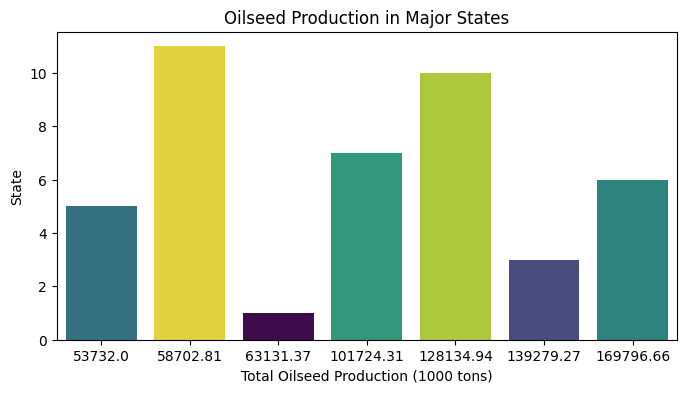

In [27]:
# 13) Oilseed Production in Major States (Bar Chart)
# Identify State & Oilseed Production Columns
state_col = [c for c in df.columns if "state" in c.lower()][0]
# Detect oilseed production columns
oilseed_prod_cols = [
    c for c in df.columns
    if "production" in c.lower()
    and any(k in c.lower() for k in [
        "soyabean", "soybean",
        "groundnut",
        "sunflower",
        "mustard", "rapeseed",
        "sesame",
        "safflower",
        "castor"
    ])
]
state_col, oilseed_prod_cols
# Aggregate Oilseed Production by State (Top 7)
oilseed_by_state = (
    df.groupby(state_col, as_index=False)[oilseed_prod_cols]
      .sum()
)

# Total oilseed production (sum of all oilseed crops)
oilseed_by_state["oilseed_production_1000_tons"] = (
    oilseed_by_state[oilseed_prod_cols].sum(axis=1)
)

# Select top 7 states
top_oilseed_states = (
    oilseed_by_state
    .sort_values("oilseed_production_1000_tons", ascending=False)
    .head(7)
)
# Round off decimal
top_oilseed_states["oilseed_production_1000_tons"] = (
    top_oilseed_states["oilseed_production_1000_tons"].round(2)
)
top_oilseed_states[[state_col, "oilseed_production_1000_tons"]]

# Bar Chart - Oilseed Production in Major States
plt.figure(figsize=(8,4))

sns.barplot(
    data=top_oilseed_states,
    x="oilseed_production_1000_tons",
    y=state_col,
    hue=state_col,        
    palette="viridis",
    legend=False
)

plt.title("Oilseed Production in Major States")
plt.xlabel("Total Oilseed Production (1000 tons)")
plt.ylabel("State")

plt.show()
plt.close()

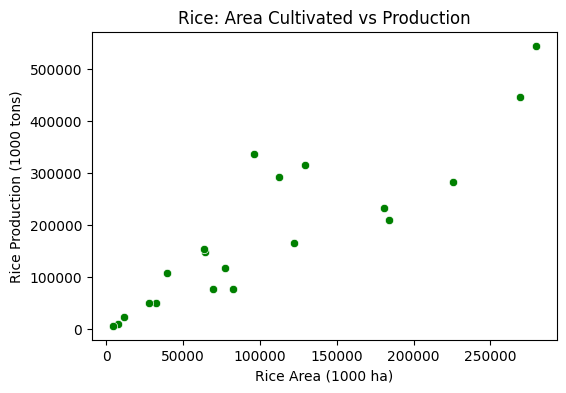

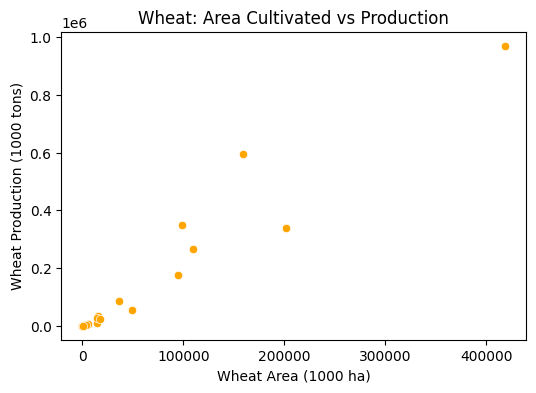

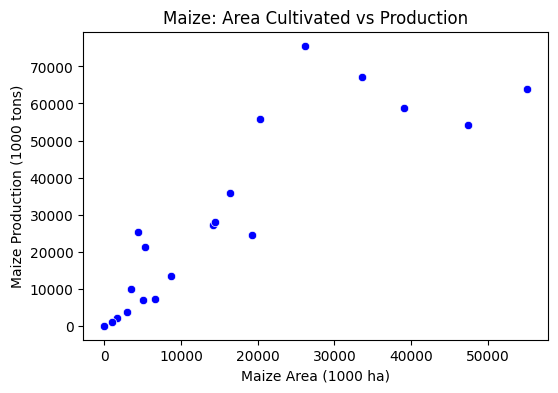

In [28]:
# 14) Impact of Area Cultivated on Production (Rice, Wheat, Maize)
# Identify Required Columns Automatically
state_col = [c for c in df.columns if "state" in c.lower()][0]

# Rice
rice_area_col = [c for c in df.columns if "rice" in c.lower() and "area" in c.lower()][0]
rice_prod_col = [c for c in df.columns if "rice" in c.lower() and "production" in c.lower()][0]

# Wheat
wheat_area_col = [c for c in df.columns if "wheat" in c.lower() and "area" in c.lower()][0]
wheat_prod_col = [c for c in df.columns if "wheat" in c.lower() and "production" in c.lower()][0]

# Maize
maize_area_col = [c for c in df.columns if "maize" in c.lower() and "area" in c.lower()][0]
maize_prod_col = [c for c in df.columns if "maize" in c.lower() and "production" in c.lower()][0]

rice_area_col, rice_prod_col, wheat_area_col, wheat_prod_col, maize_area_col, maize_prod_col

# Aggregate data state-wise
area_prod_state = (
    df.groupby(state_col)
      .agg(
          rice_area=(rice_area_col, "sum"),
          rice_production=(rice_prod_col, "sum"),
          wheat_area=(wheat_area_col, "sum"),
          wheat_production=(wheat_prod_col, "sum"),
          maize_area=(maize_area_col, "sum"),
          maize_production=(maize_prod_col, "sum")
      )
      .reset_index()
)

area_prod_state.head()
# Scatter Plot - Area Vs Production (Rice)
plt.figure(figsize=(6,4))

sns.scatterplot(
    data=area_prod_state,
    x="rice_area",
    y="rice_production",
    color="green"
)

plt.title("Rice: Area Cultivated vs Production")
plt.xlabel("Rice Area (1000 ha)")
plt.ylabel("Rice Production (1000 tons)")
plt.show()
plt.close()
# Scatter Plot - Area Vs Production (Wheat)
plt.figure(figsize=(6,4))

sns.scatterplot(
    data=area_prod_state,
    x="wheat_area",
    y="wheat_production",
    color="orange"
)
plt.title("Wheat: Area Cultivated vs Production")
plt.xlabel("Wheat Area (1000 ha)")
plt.ylabel("Wheat Production (1000 tons)")
plt.show()
plt.close()
# Scatter Plot - Area Vs Production (Maize)
plt.figure(figsize=(6,4))

sns.scatterplot(
    data=area_prod_state,
    x="maize_area",
    y="maize_production",
    color="blue"
)
plt.title("Maize: Area Cultivated vs Production")
plt.xlabel("Maize Area (1000 ha)")
plt.ylabel("Maize Production (1000 tons)")
plt.show()
plt.close()

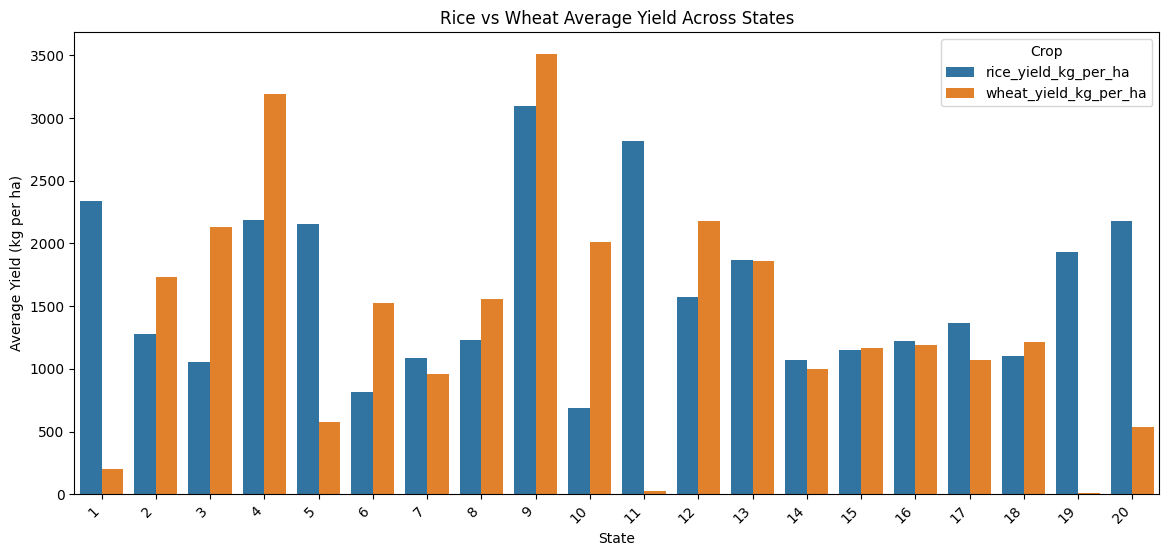

In [29]:
# 15) Rice Vs. Wheat Yield Across States
# Identify Required Columns Automatically
state_col = [c for c in df.columns if "state" in c.lower()][0]

rice_yield_col = [c for c in df.columns if "rice" in c.lower() and "yield" in c.lower()][0]
wheat_yield_col = [c for c in df.columns if "wheat" in c.lower() and "yield" in c.lower()][0]

state_col, rice_yield_col, wheat_yield_col
# Calculate Average Yield by State
yield_by_state = (
    df.groupby(state_col)
      .agg(
          rice_yield_kg_per_ha=(rice_yield_col, "mean"),
          wheat_yield_kg_per_ha=(wheat_yield_col, "mean")
      )
      .reset_index()
)
yield_by_state[["rice_yield_kg_per_ha", "wheat_yield_kg_per_ha"]] = (
    yield_by_state[["rice_yield_kg_per_ha", "wheat_yield_kg_per_ha"]].round(2)
)
# Convert to long format
yield_long = yield_by_state.melt(
    id_vars=state_col,
    value_vars=["rice_yield_kg_per_ha", "wheat_yield_kg_per_ha"],
    var_name="Crop",
    value_name="Average Yield (kg per ha)"
)
# Bar Chart
plt.figure(figsize=(14,6))
sns.barplot(
    data=yield_long,
    x=state_col,
    y="Average Yield (kg per ha)",
    hue="Crop"
)
plt.title("Rice vs Wheat Average Yield Across States")
plt.xlabel("State")
plt.ylabel("Average Yield (kg per ha)")
plt.xticks(rotation=45, ha="right")
plt.show()
plt.close()

In [30]:
import pandas as pd
import sqlite3

df = pd.read_csv("cleaned_agriculture_data.csv")

# Create SQLite database file
conn = sqlite3.connect("agriculture.db")
cols = pd.read_sql("PRAGMA table_info(agriculture_data);", conn)

# Save DataFrame as SQL table
df.to_sql("agriculture_data", conn, if_exists="replace", index=False)

conn.close()

In [31]:
# Create Database Connection
conn = sqlite3.connect("agriculture.db")
def get_connection():
    return mysql.connector.connect(
        host="localhost",
        user="root",
        password="Ak47@123",
        port=3306,     
        database="agriculture.db"
    )

In [53]:
# # Execute SQL Query in Python
# 1) Year-wise Trend of  Rice Production Across States (Top 3)

# Connect to SQLite database
conn = sqlite3.connect("agriculture.db")

q1 = """
WITH top_3_states AS (
    SELECT
        state_name
    FROM agriculture_data
    GROUP BY state_name
    ORDER BY SUM(rice_production_1000_tons) DESC
    LIMIT 3
)
SELECT
    a.year,
    a.state_name,
    ROUND(SUM(a.rice_production_1000_tons), 2) AS yearly_rice_production
FROM agriculture_data a
JOIN top_3_states t
    ON a.state_name = t.state_name
GROUP BY
    a.year,
    a.state_name
ORDER BY
    a.year ASC,
    yearly_rice_production DESC;
"""

# Read data
df_rice_trend = pd.read_sql_query(q1, conn)

# Export for Power BI
df_rice_trend.to_csv(
    "q1_yearwise_rice_production_top3_states.csv",
    index=False
)
print(df_rice_trend)

conn.close()

print("CSV file created successfully!")


     year     state_name  yearly_rice_production
0    1966    West Bengal                 4819.40
1    1966  Uttar Pradesh                 2473.50
2    1966         Punjab                  338.00
3    1967    West Bengal                 4865.77
4    1967  Uttar Pradesh                 2969.00
..    ...            ...                     ...
151  2016  Uttar Pradesh                14500.80
152  2016         Punjab                12638.00
153  2017    West Bengal                15658.94
154  2017  Uttar Pradesh                15551.39
155  2017         Punjab                13382.00

[156 rows x 3 columns]
CSV file created successfully!


In [55]:
# 2) Top 5 Districts by Wheat Yield Increase Over the Last 5 Years

conn = sqlite3.connect("agriculture.db")

q2 = """
WITH recent_years AS (
    SELECT
        dist_name,
        year,
        wheat_yield_kg_per_ha
    FROM agriculture_data
    WHERE year >= (
        SELECT MAX(year) - 4
        FROM agriculture_data
    )
),
yield_comparison AS (
    SELECT
        dist_name,
        MIN(year) AS start_year,
        MAX(year) AS end_year,
        MIN(wheat_yield_kg_per_ha) AS start_yield,
        MAX(wheat_yield_kg_per_ha) AS end_yield
    FROM recent_years
    GROUP BY dist_name
)
SELECT
    dist_name,
    start_year,
    end_year,
    ROUND(end_yield - start_yield, 2) AS wheat_yield_increase_kg_per_ha
FROM yield_comparison
ORDER BY wheat_yield_increase_kg_per_ha DESC
LIMIT 5;
"""

df_wheat_yield_growth = pd.read_sql_query(q2, conn)

# Export for Power BI
df_wheat_yield_growth.to_csv(
    "q2_wheat_yield_growth_top5_disticts.csv",
    index=False
)
print(df_wheat_yield_growth)

conn.close()

print("CSV file created successfully!")

   dist_name  start_year  end_year  wheat_yield_increase_kg_per_ha
0   Adilabad        2013      2017                         3696.11
1      Nadia        2013      2017                         3405.97
2  Hyderabad        2013      2017                         3268.42
3      Thane        2013      2017                         2833.33
4     Kanpur        2013      2017                         2750.47
CSV file created successfully!


In [72]:
# 3) States with the Highest Growth in Oilseed Production (5-Year Growth Rate)

conn = sqlite3.connect("agriculture.db")

q3 = """
WITH year_bounds AS (
    SELECT
        MAX(year) AS max_year,
        MAX(year) - 4 AS start_year
    FROM agriculture_data
),
oilseed_yearly AS (
    SELECT
        a.state_name,
        a.year,
        SUM(a.oilseeds_production_1000_tons) AS total_oilseed_production
    FROM agriculture_data a
    JOIN year_bounds y
        ON a.year IN (y.start_year, y.max_year)
    GROUP BY a.state_name, a.year
),
pivoted AS (
    SELECT
        state_name,
        MAX(CASE WHEN year = (SELECT start_year FROM year_bounds)
                 THEN total_oilseed_production END) AS production_start,
        MAX(CASE WHEN year = (SELECT max_year FROM year_bounds)
                 THEN total_oilseed_production END) AS production_end
    FROM oilseed_yearly
    GROUP BY state_name
)
SELECT
    state_name,
    ROUND(
        ((production_end - production_start) * 100.0) / production_start,
        2
    ) AS oilseed_growth_rate_percent
FROM pivoted
WHERE production_start IS NOT NULL
  AND production_end IS NOT NULL
  AND production_start > 0
ORDER BY oilseed_growth_rate_percent DESC
LIMIT 5;
"""

df_oilseed_growth = pd.read_sql(q3, conn)
# Export for Power BI
df_oilseed_growth.to_csv(
    "q3_oilseed_production_5year_growth_rate.csv",
    index=False
)
print(df_oilseed_growth)

conn.close()

print("CSV file created successfully!")

       state_name  oilseed_growth_rate_percent
0  Andhra Pradesh                        28.29
1         Haryana                        26.20
2          Orissa                       -23.37
3           Assam                      -100.00
4           Bihar                      -100.00
CSV file created successfully!


In [87]:
# 4) District-wise Correlation Between Area and Production for Major Crops (Rice, Wheat, and Maize) 

conn = sqlite3.connect("agriculture.db")

q4 = """
WITH base AS (
    SELECT dist_name, 'Rice' AS crop, year,
           rice_area_1000_ha AS area,
           rice_production_1000_tons AS production
    FROM agriculture_data
    WHERE rice_area_1000_ha IS NOT NULL
      AND rice_production_1000_tons IS NOT NULL

    UNION ALL
    SELECT dist_name, 'Wheat' AS crop, year,
           wheat_area_1000_ha AS area,
           wheat_production_1000_tons AS production
    FROM agriculture_data
    WHERE wheat_area_1000_ha IS NOT NULL
      AND wheat_production_1000_tons IS NOT NULL

    UNION ALL
    SELECT dist_name, 'Maize' AS crop, year,
           maize_area_1000_ha AS area,
           maize_production_1000_tons AS production
    FROM agriculture_data
    WHERE maize_area_1000_ha IS NOT NULL
      AND maize_production_1000_tons IS NOT NULL
),
stats AS (
    SELECT
        dist_name,
        crop,
        COUNT(*) AS n,
        SUM(area) AS sum_x,
        SUM(production) AS sum_y,
        SUM(area * production) AS sum_xy,
        SUM(area * area) AS sum_x2,
        SUM(production * production) AS sum_y2
    FROM base
    GROUP BY dist_name, crop
)
SELECT
    dist_name,
    crop,
    ROUND(
        (n * sum_xy - sum_x * sum_y) /
        SQRT(
            (n * sum_x2 - sum_x * sum_x) *
            (n * sum_y2 - sum_y * sum_y)
        ),
        3
    ) AS area_production_correlation
FROM stats
WHERE n >= 5
  AND (n * sum_x2 - sum_x * sum_x) > 0
  AND (n * sum_y2 - sum_y * sum_y) > 0
ORDER BY crop, area_production_correlation DESC;
"""

df_corr_area_production_major_crops = pd.read_sql(q4, conn)
# Export for Power BI
df_corr_area_production_major_crops.to_csv(
    "q4_correlation_area_production_crops.csv",
    index=False
)
print(df_corr_area_production_major_crops)
conn.close()
print("CSV file created successfully!")

         dist_name   crop  area_production_correlation
0           Bombay  Maize                        1.000
1      Cooch Behar  Maize                        0.999
2          Gwalior  Maize                        0.999
3       Srikakulam  Maize                        0.998
4       Chhatarpur  Maize                        0.996
..             ...    ...                          ...
890          Sagar  Wheat                        0.156
891       Dehradun  Wheat                        0.142
892           Tonk  Wheat                       -0.000
893          Damoh  Wheat                       -0.181
894  Muzaffarnagar  Wheat                       -0.247

[895 rows x 3 columns]
CSV file created successfully!


In [100]:
# 5) Yearly Production Growth of Cotton in Top 5 Cotton Producing States

conn = sqlite3.connect("agriculture.db")

q5 = """
WITH top_5_states AS (
    -- Top 5 cotton producing states overall
    SELECT
        state_name
    FROM agriculture_data
    GROUP BY state_name
    ORDER BY SUM(cotton_production_1000_tons) DESC
    LIMIT 5
),
state_year_prod AS (
    -- Yearly cotton production for top 5 states
    SELECT
        a.state_name,
        a.year,
        SUM(a.cotton_production_1000_tons) AS production
    FROM agriculture_data a
    JOIN top_5_states t
        ON a.state_name = t.state_name
    GROUP BY a.state_name, a.year
),
yoy_growth AS (
    -- Self-join to calculate year-over-year growth
    SELECT
        cur.state_name,
        cur.year,
        cur.production AS current_production,
        prev.production AS previous_production,
        ROUND(
            ((cur.production - prev.production) * 100.0) /
            NULLIF(prev.production, 0),
            2
        ) AS yoy_growth_percent
    FROM state_year_prod cur
    JOIN state_year_prod prev
        ON cur.state_name = prev.state_name
       AND cur.year = prev.year + 1
)
SELECT
    state_name,
    year,
    current_production,
    yoy_growth_percent
FROM yoy_growth
ORDER BY state_name, year;
"""

df_cotton_growth = pd.read_sql(q5, conn)
# Export for Power BI
df_cotton_growth.to_csv(
    "q5_cotton_production_growth_top5_states.csv",
    index=False
)
print(df_cotton_growth)
conn.close()

print("CSV file created successfully!")

    state_name  year  current_production  yoy_growth_percent
0      Gujarat  1967              271.00                7.54
1      Gujarat  1968              264.00               -2.58
2      Gujarat  1969              295.30               11.86
3      Gujarat  1970              323.90                9.69
4      Gujarat  1971              451.40               39.36
..         ...   ...                 ...                 ...
250  Telangana  2013              767.75               11.31
251  Telangana  2014              645.00              -15.99
252  Telangana  2015              671.94                4.18
253  Telangana  2016              619.98               -7.73
254  Telangana  2017              935.19               50.84

[255 rows x 4 columns]
CSV file created successfully!


In [111]:
# 6) Districts with the Highest Groundnut Production in 2017

conn = sqlite3.connect("agriculture.db")

q6 = """
SELECT
    dist_name,
    ROUND(SUM(groundnut_production_1000_tons), 2) AS groundnut_production_2017
FROM agriculture_data
WHERE year = 2017
  AND groundnut_production_1000_tons IS NOT NULL
GROUP BY dist_name
ORDER BY groundnut_production_2017 DESC
LIMIT 10;
"""

df_groundnut_2017 = pd.read_sql(q6, conn)
# Export for Power BI
df_groundnut_2017.to_csv(
    "q6_highest_groundnut_production_2017.csv",
    index=False
)
print(df_groundnut_2017)
conn.close()

print("CSV file created successfully!")

               dist_name  groundnut_production_2017
0               Jamnagar                     977.65
1               Junagadh                     945.49
2                 Rajkot                     873.87
3                Bikaner                     514.09
4             Ananthapur                     454.94
5            Banaskantha                     288.21
6  North Arcot / Vellore                     280.51
7           Mahabubnagar                     273.25
8               Chittoor                     263.38
9            Sabarkantha                     244.48
CSV file created successfully!


In [116]:
# 7) Annual Average Maize Yield Across All States

conn = sqlite3.connect("agriculture.db")

q7 = """
SELECT
    year,
    state_name,
    ROUND(AVG(maize_yield_kg_per_ha), 2) AS avg_maize_yield_kg_per_ha
FROM agriculture_data
WHERE maize_yield_kg_per_ha IS NOT NULL
GROUP BY
    year,
    state_name
ORDER BY
    year ASC,
    avg_maize_yield_kg_per_ha DESC;
"""

df_maize_state_year = pd.read_sql(q7, conn)
# Export for Power BI
df_maize_state_year.to_csv(
    "q7_annual_avg_maize_yield_states.csv",
    index=False
)
print(df_maize_state_year)
conn.close()

print("CSV file created successfully!")

      year        state_name  avg_maize_yield_kg_per_ha
0     1966  Himachal Pradesh                    1350.23
1     1966            Punjab                    1332.56
2     1966      Chhattisgarh                    1129.94
3     1966         Jharkhand                    1029.92
4     1966             Bihar                    1011.68
...    ...               ...                        ...
1033  2017       Uttarakhand                    1952.38
1034  2017         Rajasthan                    1798.30
1035  2017           Gujarat                    1680.53
1036  2017           Haryana                    1126.37
1037  2017            Kerala                     719.21

[1038 rows x 3 columns]
CSV file created successfully!


In [120]:
# 8) Total Area Cultivated for Oilseeds in Each State

conn = sqlite3.connect("agriculture.db")

q8 = """
SELECT
    state_name,
    ROUND(
        SUM(
            COALESCE(groundnut_area_1000_ha, 0) +
            COALESCE(soyabean_area_1000_ha, 0) +
            COALESCE(sunflower_area_1000_ha, 0) +
            COALESCE(rapeseed_and_mustard_area_1000_ha,  0) +
            COALESCE(sesamum_area_1000_ha, 0) +
            COALESCE(safflower_area_1000_ha, 0) +
            COALESCE(castor_area_1000_ha, 0)
        ),
        2
    ) AS total_oilseed_area_1000_ha
FROM agriculture_data
GROUP BY state_name
ORDER BY total_oilseed_area_1000_ha DESC;
"""

df_oilseed_area = pd.read_sql(q8, conn)
# Export for Power BI
df_oilseed_area.to_csv(
    "q8_area_cultivated_oilseed_state.csv",
    index=False
)
print(df_oilseed_area)
conn.close()

print("CSV file created successfully!")

          state_name  total_oilseed_area_1000_ha
0     Madhya Pradesh                   187535.32
1          Rajasthan                   140216.97
2            Gujarat                   133618.69
3        Maharashtra                   126395.65
4          Karnataka                    91826.94
5     Andhra Pradesh                    82545.39
6         Tamil Nadu                    49157.49
7      Uttar Pradesh                    44687.95
8          Telangana                    35134.75
9             Orissa                    30787.98
10       West Bengal                    21321.44
11           Haryana                    20881.01
12             Assam                    13457.55
13            Punjab                     8788.21
14      Chhattisgarh                     7472.41
15             Bihar                     4623.36
16       Uttarakhand                     1822.70
17         Jharkhand                     1721.96
18            Kerala                      856.25
19  Himachal Pradesh

In [128]:
# 9) Districts with the Highest Rice Yield

conn = sqlite3.connect("agriculture.db")

q9 = """
SELECT
    dist_name,
    ROUND(AVG(rice_yield_kg_per_ha), 2) AS avg_rice_yield_kg_per_ha
FROM agriculture_data
WHERE rice_yield_kg_per_ha IS NOT NULL
GROUP BY dist_name
HAVING COUNT(rice_yield_kg_per_ha) >= 5
ORDER BY avg_rice_yield_kg_per_ha DESC
LIMIT 10;
"""

df_top_rice_yield = pd.read_sql(q9, conn)

# Export for Power BI
df_top_rice_yield.to_csv(
    "q9_highest_rice_yield_district.csv",
    index=False
)
print(df_top_rice_yield)
conn.close()

print("CSV file created successfully!")

      dist_name  avg_rice_yield_kg_per_ha
0      Ludhiana                   3650.43
1       Sangrur                   3532.90
2  Thirunelveli                   3387.51
3      Bhatinda                   3363.16
4       Madurai                   3276.98
5   Kanyakumari                   3240.69
6      Ferozpur                   3234.06
7       Patiala                   3222.13
8     Jalandhar                   3187.03
9         Salem                   3102.58
CSV file created successfully!


In [129]:
# 10) Compare the Production of Wheat and Rice for the Top 5 States Over 10 Years

conn = sqlite3.connect("agriculture.db")

q10 = """
WITH year_range AS (
    SELECT MAX(year) AS max_year
    FROM agriculture_data
),
last_10_years AS (
    SELECT
        state_name,
        rice_production_1000_tons,
        wheat_production_1000_tons
    FROM agriculture_data
    WHERE year >= (SELECT max_year - 9 FROM year_range)
)
SELECT
    state_name,
    ROUND(SUM(rice_production_1000_tons), 2) AS total_rice_production_1000_tons,
    ROUND(SUM(wheat_production_1000_tons), 2) AS total_wheat_production_1000_tons,
    ROUND(
        SUM(rice_production_1000_tons) +
        SUM(wheat_production_1000_tons), 2
    ) AS total_combined_production_1000_tons
FROM last_10_years
GROUP BY state_name
ORDER BY total_combined_production_1000_tons DESC
LIMIT 5;
"""
df_top5_states = pd.read_sql(q10, conn)

# Export for Power BI
df_top5_states.to_csv(
    "q10_wheat_rice_over_10years_top5_states.csv",
    index=False
)
print(df_top5_states)
conn.close()

print("CSV file created successfully!")

       state_name  total_rice_production_1000_tons  \
0   Uttar Pradesh                        134935.48   
1          Punjab                        115204.00   
2  Madhya Pradesh                         30005.99   
3     West Bengal                        150342.14   
4         Haryana                         39597.00   

   total_wheat_production_1000_tons  total_combined_production_1000_tons  
0                         298625.49                            433560.97  
1                         165983.00                            281187.00  
2                         148622.84                            178628.83  
3                           8127.72                            158469.86  
4                         115917.00                            155514.00  
CSV file created successfully!
